# Auto-R diagnostic, arm 2/2 — `WeightedFPSRefs`: does coverage + $p$-mass weights beat i.i.d.?

Companion to `refset_auto_r_diagnostic.ipynb` (`RandomRefs`), run as a **separate Slurm job in parallel**. Both
import `auto_r_common.py`, so both see a bit-identical $f$ and — because the shared `MemoSampler` is seeded
identically — rank the **same** 128 probe points. The two $\tau$ curves are therefore directly comparable.

**What this selector does differently.** `RandomRefs` samples $p$; `WeightedFPSRefs` *covers* it: greedy
farthest-point selection in the IEM metric, then each reference $x'_m$ is weighted by the $p$-mass of its IEM-Voronoi
cell, so the weighted mean still estimates $E_{x'\sim p}[D]$ rather than a mode-balanced average. It is
**consistent** rather than unbiased, and it carries a within-cell quantization bias at finite $R$ — a different,
smaller bias than plain FPS's. The question it answers: does spending effort on *which* references, rather than
*how many*, give a better-conditioned reward at the $R$ we can afford?

**Its auto-R is optimistic and its own docstring says so:** the nested $R$-vs-$2R$ test shares $R$ reference terms,
which is intrinsic to deterministic FPS and not removable (the library *does* remove the separate weight-noise
correlation, by estimating the $R$- and $2R$-side weights from two independent estimation sets). **Read its $R$ as a
lower bound.** The RandomRefs arm's independent-draw curve is what calibrates how large that bias is.

## Why the ladder stops at $R = 32$

Unlike the Random arm, this one is not bounded by VRAM — it is bounded by the two things that scale with the top
of the ladder, both charged at 87 transformer rows per point:

- **The pool.** FPS must choose $2R_{\max}$ references out of a pool it can see, and the whole pool must be scored
  (`_ensure_order` calls `pairwise(pool, new_ref)` once per greedy pick). If $2R_{\max}$ approaches the pool size,
  "farthest point" degenerates into "take everything", and the top-$R$ $\tau$ becomes meaningless. Here $64$ of
  $160$.
- **The Voronoi estimation sets.** Weights need $M_{est} \gg 2R$ points assigned to cells, and there are **two**
  independent sets (the de-correlation above). At `points_per_cell=4` and $R_{\max}=32$ that is $2 \times 128$
  points — 2 per cell on the $2R = 64$ side, already the noisy end.

Measured (CPU dry run at the real grid sizes, so the row counts are exact):

| configuration | points banked | projected |
|---|---|---|
| pool 160, grid ≤ **32**, ppc 4 | 696 | **4.2 h** ← this notebook |
| pool 192, grid ≤ 16, ppc 4 | 560 | 3.4 h |
| pool 256, grid ≤ 64, ppc 2 | 944 | 5.6 h — and only ~1 estimation point per cell at $2R = 128$ |

So $R = 64$ for *this* selector costs ~6 h and would be **weight-noise-limited** at the top anyway. Smaller entries
in the grid are free (they are column slices of the same block), so `(4, 8, 16, 32)` costs exactly what `(32)` costs.


In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import torch

T_START = time.time()

OUT_DIR = os.path.abspath(os.getcwd())
REPO = os.path.abspath(os.path.join(OUT_DIR, "..", ".."))
for _p in (REPO, OUT_DIR):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from huggingface_hub import auth_check

auth_check("black-forest-labs/FLUX.1-dev")

import auto_r_common as common      # the setup BOTH arms share -> identical f, identical probes

setup = common.build()
p_gen, D2 = setup.p_gen, setup.distance

# --- arm controls -----------------------------------------------------------------------------------
ARM = "fps"
FPS_GRID = (4, 8, 16, 32)     # top drives the cost; smaller entries are column slices
FPS_POOL = 160                # must EXCEED 2*max(grid) with room to spare, or FPS just takes the pool
FPS_PPC = 4                   # estimation points per Voronoi cell -> M_est = max(floor, ppc*max(grid))
FPS_FLOOR = 128               # library defaults are 64 / 1000; 1000 est points = 6.1 h on their own
FPS_START = 0                 # seed the greedy run at pool[0] instead of an O(N^2) outlier search

_fmax = max(FPS_GRID)
M_EST = max(FPS_FLOOR, FPS_PPC * _fmax)
assert 2 * _fmax < FPS_POOL, (
    f"FPS needs pool_size strictly greater than 2*max(FPS_GRID)={2 * _fmax}; at equality FPS selects "
    f"the whole pool and the largest-R tau is meaningless. Got pool={FPS_POOL}.")

# --- cost projection --------------------------------------------------------------------------------
# Points banked, from the CPU dry run at exactly these controls (the row count depends only on the
# point counts, not on d, so it transfers exactly):
#   pool 160 + 2 estimation sets of 128 + 128 probes           = 544  (cached, scored once each)
#   + one bank per greedy pick (64) + the D_est columns (96) + the tau block's 64 references
# The per-pick banks are why the pool cache matters: uncached, each of the 64 picks would re-score all
# 160 pool points -- 87*160 rows per pick, ~48 h.
POINTS = 696
ROWS = POINTS * (common.GEN_ROWS + common.BANK_ROWS)
print(f"\npool {FPS_POOL}, grid {FPS_GRID} (2*max = {2 * _fmax} references), "
      f"M_est = {M_EST} x 2 roles")
print(f"  ~{POINTS} points to bank -> {ROWS:,} rows -> {common.hours(ROWS):.2f} h at "
      f"{common.S_ROW} s/row ({ROWS * 0.25 / 3600:.2f} h at 0.25)")
_resident = (FPS_POOL + 2 * M_EST + common.PROBE_SIZE) * common.BANK_BYTES_PER_POINT
print(f"  VRAM: pool + 2 estimation sets + probes = {_resident / 2**30:.1f} GB of banks held at once "
      f"(cache budget {D2.cache_bytes / 2**30:.1f} GB)")
if _resident > D2.cache_bytes:
    print("  WARNING: the working set exceeds the cache budget -> LRU will thrash and re-score. "
          "Lower FPS_POOL or FPS_PPC.")
print(f"  weight resolution: {M_EST / _fmax:.1f} estimation points per cell at R={_fmax}, "
      f"{M_EST / (2 * _fmax):.1f} at 2R={2 * _fmax}")


/home/dcor/arielzoizner/miniconda3/envs/creativity-measure/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading pipeline components...:  14%|█▍        | 1/7 [00:00<00:02,  2.31it/s]

Loading pipeline components...:  29%|██▊       | 2/7 [00:01<00:04,  1.11it/s]

...

Loading checkpoint shards: 100%|██████████| 3/3 [00:07<00:00,  2.43s/it]


Loading pipeline components...:  86%|████████▌ | 6/7 [00:12<00:03,  3.07s/it]

Loading pipeline components...: 100%|██████████| 7/7 [00:12<00:00,  2.19s/it]

Loading pipeline components...: 100%|██████████| 7/7 [00:12<00:00,  1.79s/it]

device cuda  d=65536  prompt='A dog' guidance=1.5 img=512
N_GAMMA=30 NUM_EPS=3  denoiser batch capped at 24 rows
data scale S=1.028 (sweep 695271: 1.015)  gamma=[0.9457, 1024] x 30 nodes
probes: 128 points from seed 9990 (both arms rank THESE points)
cost per point: 15 gen + 87 bank rows = 22.4 s   bank VRAM 22 MB/pt
VRAM 30.6 GB used / 44.5 GB; bank cache budget 6.0 GB

pool 160, grid (4, 8, 16, 32) (2*max = 64 references), M_est = 128 x 2 roles
  ~696 points to bank -> 70,992 rows -> 4.34 h at 0.22 s/row (4.93 h at 0.25)
  VRAM: pool + 2 estimation sets + probes = 11.6 GB of banks held at once (cache budget 6.0 GB)
  weight resolution: 4.0 estimation points per cell at R=32, 2.0 at 2R=64


In [2]:
from creativity_measure.refset import WeightedFPSRefs

# Deterministic given the pool, so auto-R runs ONE draw (`_auto_r_effective_draws` -> 1) -- there is no
# independent-draw check available here, which is exactly why the Random arm runs two.
sel_fps = WeightedFPSRefs(
    p_gen, distance=D2, pool_size=FPS_POOL, start=FPS_START,
    points_per_cell=FPS_PPC, est_floor=FPS_FLOOR,
    seed=common.SEED, auto_r_grid=FPS_GRID, tau_target=common.TAU_TARGET,
    probe_size=common.PROBE_SIZE, fallback="best",
)

t0 = time.time()
R_fps = sel_fps.select(None).shape[0]
dt_fps = time.time() - t0

rows_done = D2.rows_scored + p_gen.rows_generated
print(f"WeightedFPSRefs auto-R -> R = {R_fps}   ({dt_fps / 60:.1f} min, projected "
      f"{common.hours(ROWS) * 60:.0f} min)   [treat as a LOWER BOUND: nested references]")
print(f"realized {dt_fps / max(rows_done, 1):.3f} s/row over {rows_done:,} rows "
      f"(assumed {common.S_ROW})")
print(D2.stats())

print(f"\n{'R':>5} {'tau(f_R, f_2R)':>15}  {'>= target':>9}")
for R, tau in sel_fps.tau_history:
    print(f"{R:5d} {tau:15.4f}  {'yes' if tau >= common.TAU_TARGET else 'no':>9}")
ceiling_fps = max((t for _, t in sel_fps.tau_history), default=float("nan"))
print(f"\nobserved tau ceiling: {ceiling_fps:.4f}   (target {common.TAU_TARGET})")

payload = {
    "config": common.config_dict(),
    "arm": ARM,
    "controls": {"grid": list(FPS_GRID), "pool": FPS_POOL, "points_per_cell": FPS_PPC,
                 "est_floor": FPS_FLOOR, "m_est": M_EST, "start": FPS_START},
    "nested_tau": sel_fps.tau_history,
    "auto_R": R_fps,
    "ceiling": ceiling_fps,
    "minutes": dt_fps / 60,
    "rows": rows_done,
    "s_per_row": dt_fps / max(rows_done, 1),
}
common.save_results(OUT_DIR, ARM, payload)      # persist before the diagnostics below


WeightedFPSRefs auto-R -> R = 4   (192.2 min, projected 260 min)   [treat as a LOWER BOUND: nested references]
realized 0.170 s/row over 67,668 rows (assumed 0.22)
bank cache: 63 hits / 71 misses, 67 evictions, 5.69 GB resident of 6.0 GB, 59,508 rows scored

    R  tau(f_R, f_2R)  >= target
    4          0.9861        yes

observed tau ceiling: 0.9861   (target 0.9)
  saved -> auto_r_results_fps.json


'/home/dcor/arielzoizner/projects/creativity-measure/notebooks/refset_auto_r/auto_r_results_fps.json'

Voronoi weights at R=4: min=0.0000 max=0.8984 max/min=898437500000.0
  effective references R_eff = 1.2 of 4   (2 empty cells)
  -> a large max/min means p-mass is very unevenly spread over the FPS cells, i.e. plain (unweighted) FPS
     would have badly over-represented sparse regions of p. A small R_eff means the weighting has
     undone much of the coverage it paid for.
  weights: [0.8984, 0.1016, 0.0, 0.0]
  estimated from M_est = 128 points -> +/- 0.088 relative per cell

covering radius rho(R) = max_pool min_chosen D^2_IEM (falls as R grows; where it flattens,
more references stop buying coverage):
  R=  1  rho=321326.0625   (0% below rho(1))
  R=  2  rho=317999.7188   (1% below rho(1))
  R=  4  rho=316737.6250   (1% below rho(1))
  R=  8  rho=315428.4375   (2% below rho(1))
  R= 16  rho=311954.1875   (3% below rho(1))
  R= 32  rho=309242.1875   (4% below rho(1))
  R= 64  rho=304963.7188   (5% below rho(1))


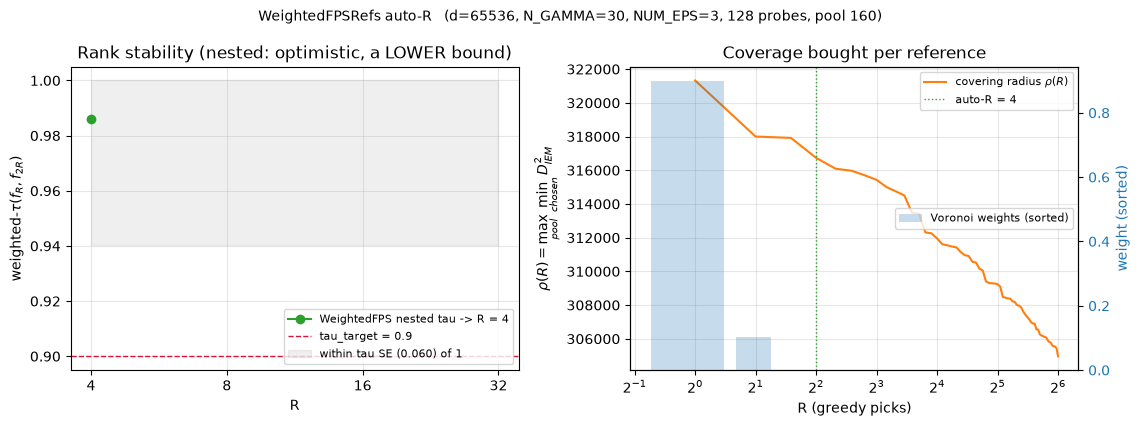

  saved -> auto_r_results_fps.json

total notebook time: 208.8 min   |   bank cache: 63 hits / 71 misses, 67 evictions, 5.69 GB resident of 6.0 GB, 59,508 rows scored


In [3]:
# --- what the weights and the coverage look like ------------------------------------------------------
# Free (no IEM evaluations): everything here is already-computed state on the selector.
#
# R_eff = (sum w)^2 / sum w^2 is the diagnostic the tau curve cannot show. FPS's promise is that R
# well-chosen references beat R random ones; but if the p-mass concentrates in a few Voronoi cells, the
# weighted mean is effectively an R_eff-reference estimator, and comparing it to RandomRefs at R is
# comparing the wrong numbers. Empty cells (weight exactly 0) are references that contribute NOTHING.
w = sel_fps.weights
w_list = None
R_eff = float("nan")
if w is not None:
    w = w.detach().float().cpu()
    w_list = [float(x) for x in w]
    R_eff = float(w.sum() ** 2 / (w ** 2).sum())
    empty = int((w == 0).sum())
    print(f"Voronoi weights at R={R_fps}: min={float(w.min()):.4f} max={float(w.max()):.4f} "
          f"max/min={float(w.max()) / max(float(w.min()), 1e-12):.1f}")
    print(f"  effective references R_eff = {R_eff:.1f} of {R_fps}   ({empty} empty cells)")
    print(f"  -> a large max/min means p-mass is very unevenly spread over the FPS cells, i.e. plain "
          f"(unweighted) FPS\n     would have badly over-represented sparse regions of p. A small "
          f"R_eff means the weighting has\n     undone much of the coverage it paid for.")
    print(f"  weights: {[round(x, 4) for x in w_list]}")
    print(f"  estimated from M_est = {M_EST} points -> +/- {1 / M_EST ** 0.5:.3f} relative per cell")

rho = list(getattr(sel_fps, "covering_radius_history", []) or [])
if rho:
    print(f"\ncovering radius rho(R) = max_pool min_chosen D^2_IEM (falls as R grows; where it flattens,")
    print(f"more references stop buying coverage):")
    for R in [r for r in (1, 2, 4, 8, 16, 32, 64) if r <= len(rho)]:
        print(f"  R={R:3d}  rho={rho[R - 1]:.4f}"
              + (f"   ({100 * (1 - rho[R - 1] / rho[0]):.0f}% below rho(1))" if rho[0] else ""))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

ax.plot([R for R, _ in sel_fps.tau_history], [t for _, t in sel_fps.tau_history], "o-",
        color="tab:green", label=f"WeightedFPS nested tau -> R = {R_fps}")
ax.axhline(common.TAU_TARGET, color="crimson", ls="--", lw=1,
           label=f"tau_target = {common.TAU_TARGET}")
se = (2 * (2 * common.PROBE_SIZE + 5) / (9 * common.PROBE_SIZE * (common.PROBE_SIZE - 1))) ** 0.5
ax.fill_between([min(FPS_GRID), max(FPS_GRID)], 1 - se, 1, color="grey", alpha=0.12,
                label=f"within tau SE ({se:.3f}) of 1")
ax.set_xscale("log", base=2)
ax.set_xticks(list(FPS_GRID)); ax.set_xticklabels([str(r) for r in FPS_GRID])
ax.set_xlabel("R"); ax.set_ylabel(r"weighted-$\tau(f_R, f_{2R})$")
ax.set_title("Rank stability (nested: optimistic, a LOWER bound)")
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")

if rho:
    ax2.plot(range(1, len(rho) + 1), rho, "-", color="tab:orange", label=r"covering radius $\rho(R)$")
    ax2.set_xscale("log", base=2); ax2.set_xlabel("R (greedy picks)")
    ax2.set_ylabel(r"$\rho(R) = \max_{pool}\min_{chosen} D^2_{IEM}$")
    ax2.axvline(R_fps, color="tab:green", ls=":", lw=1, label=f"auto-R = {R_fps}")
    ax2.set_title("Coverage bought per reference")
    ax2.grid(alpha=0.3, which="both"); ax2.legend(fontsize=8)
if w_list is not None:
    ax3 = ax2.twinx()
    ax3.bar(range(1, len(w_list) + 1), sorted(w_list, reverse=True), alpha=0.25, color="tab:blue",
            width=0.8, label="Voronoi weights (sorted)")
    ax3.set_ylabel("weight (sorted)", color="tab:blue")
    ax3.tick_params(axis="y", labelcolor="tab:blue")
    ax3.legend(fontsize=8, loc="center right")

fig.suptitle(f"WeightedFPSRefs auto-R   (d={common.LATENT_DIM}, N_GAMMA={common.N_GAMMA}, "
             f"NUM_EPS={common.NUM_EPS}, {common.PROBE_SIZE} probes, pool {FPS_POOL})", fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "auto_r_tau_fps.png"), dpi=140, bbox_inches="tight")
plt.show()

payload["weights"] = w_list
payload["R_eff"] = R_eff
payload["covering_radius"] = [float(r) for r in rho] if rho else None
payload["tau_probe_se"] = se
common.save_results(OUT_DIR, ARM, payload)
print(f"\ntotal notebook time: {(time.time() - T_START) / 60:.1f} min   |   {D2.stats()}")


In [4]:
# --- cross-arm figure, if the RandomRefs job has already landed ---------------------------------------
# Opportunistic: the two arms are separate jobs, so whichever finishes second draws the joint plot.
# `python compare_arms.py` does the same standalone (CPU, seconds) once both JSONs exist.
_rand_path = common.results_path(OUT_DIR, "random")
if os.path.exists(_rand_path):
    import compare_arms

    compare_arms.plot(OUT_DIR)
else:
    print(f"{os.path.basename(_rand_path)} not present yet -- the RandomRefs job is still running.\n"
          f"Run `python compare_arms.py` in this directory once it lands.")


auto_r_results_random.json not present yet -- the RandomRefs job is still running.
Run `python compare_arms.py` in this directory once it lands.


## Takeaways

*(Fill in after the run — this cell is the authoritative statement of what was learned, per repo convention.)*

**What this decides.** Whether *choosing* references (coverage + $p$-mass weights) buys rank stability that
*counting* them (i.i.d.) does not — and therefore whether the sweeps should switch selector, or just raise $R$.

**To record:**

- The auto-chosen $R$ and the $\tau$ curve, remembering both are **optimistic** (nested references). The Random
  arm's independent-draw curve is what calibrates the size of that bias; apply the same correction here.
- $\tau$ at $R = 8, 16, 32$ **against `RandomRefs` at the same $R$** — the arms rank the same probe points, so this
  is a direct comparison. FPS wins only if its curve sits *above* Random's at equal $R$.
- **$R_{\text{eff}}$ vs $R$.** If the $p$-mass concentrates in a few Voronoi cells, the weighted mean is
  effectively an $R_{\text{eff}}$-reference estimator, and "FPS at 32" is really "FPS at $R_{\text{eff}}$" —
  which is the number that should be compared against Random.
- **The weight spread** (`max/min`, empty cells): large means plain unweighted FPS would have badly
  over-represented sparse regions of $p$, i.e. the weighting is doing real work.
- **$\rho(R)$**, the covering radius: where it flattens is where extra references stop buying coverage. If $\rho$
  is still falling steeply at $R = 32$, the pool's IEM geometry is not covered at any affordable $R$, and coverage
  is the wrong strategy at $d = 65536$.

**Then:**

- **FPS above Random at equal $R$** → switch the sweeps' selector. Construction is expensive but paid **once**,
  outside the SMC loop; afterwards a reward call costs exactly what `RandomRefs` costs at the same $R$.
- **FPS at or below Random** → keep `RandomRefs` and buy stability with $R$, which is now cheap (per-sweep cost is
  independent of $R$; ~22 s and 22.8 MB of VRAM per reference, one-off).

**Caveats.** The Voronoi weights are estimated from $M_{est} = 128$ points per role — about 4 per cell at $R = 32$
and 2 at $2R = 64$, so the $2R$ side of every $\tau$ is the noisier one, and the top of the ladder is the least
trustworthy point on it. The pool is 160 points, so at $2R = 64$ FPS is choosing 40% of what it can see; the
"farthest point" premise is weakest exactly where the ladder ends. Both are cost limits (see the table in the
header), not oversights.
